In [1]:
from pathlib import Path
import pandas as pd

In [2]:
def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Tagesschau"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df.head()


Loaded 6320 rows from 2 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Tagesschau


,sophoraId,externalId,title,date,tags,updateCheckUrl,content,tracking,topline,firstSentence,...,teaserImage.type,teaserImage.title,comments,brandingImage.title,brandingImage.copyright,brandingImage.alttext,brandingImage.imageVariants.original,brandingImage.type,source,source_file
0,afghanistan-flieger-pakistan-100,6463c06f-784f-4813-b7e2-d0fc2070c6fa,Deutschland holt zehn afghanische Familien aus...,2025-09-01T09:00:06.043+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Menschenrech...",https://www.tagesschau.de/api2u/afghanistan-fl...,[{'value': '<strong>Zehn afghanische Familien ...,[{'sid': 'app.ausland.afghanistan-flieger-paki...,Flieger auf dem Weg nach Hannover,Zehn afghanische Familien dürfen aus Pakistan ...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
1,afghanistan-internet-104,80ab56f5-16bd-4343-994d-c202745c3362,Afghanistan ist wieder online,2025-10-01T18:30:21.655+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Internet'}]",https://www.tagesschau.de/api2u/afghanistan-in...,[{'value': '<strong>Handys und Internet funkti...,[{'sid': 'app.ausland.afghanistan-internet-104...,Nach Chaos im Land,Die Taliban begründeten den Ausfall mit techni...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
2,aethiopien-deutsche-welle-korrespondenten-100,333b0442-121b-42f7-9395-379d426bbef2,Äthiopien suspendiert Deutsche-Welle-Journalisten,2025-10-24T19:37:10.246+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Deutsche Welle'}]",https://www.tagesschau.de/api2u/aethiopien-deu...,[{'value': '<strong>Die Deutsche Welle darf vo...,[{'sid': 'app.ausland.afrika.aethiopien-deutsc...,Medienbehörde EMA,Die Deutsche Welle darf vorerst nicht mehr dir...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
3,aethiopien-kirche-einsturz-100,7cd86ce3-d711-42c7-9006-020ef1a7a713,Mindestens 30 Tote bei Einsturz von Baugerüst,2025-10-02T02:18:37.979+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Kirche'}, {'ta...",https://www.tagesschau.de/api2u/aethiopien-kir...,[{'value': '<strong>Viele Menschen befanden si...,[{'sid': 'app.ausland.afrika.aethiopien-kirche...,Äthiopien,"Obwohl die Kirche renoviert wurde, hatten sich...",...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
4,agoa-usa-afrika-100,5068ef2d-48ce-4004-a227-48849a4c5e4b,Brechen afrikanische Exporte in die USA ein?,2025-09-30T15:28:43.132+02:00,"[{'tag': 'AGOA'}, {'tag': 'Afrika'}, {'tag': '...",https://www.tagesschau.de/api2u/agoa-usa-afrik...,[{'value': '<strong>Seit Jahrzehnten verkaufen...,[{'sid': 'app.ausland.afrika.agoa-usa-afrika-1...,Aus für Handelsabkommen AGOA,Seit Jahrzehnten verkaufen mehr als die Hälfte...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv


In [3]:
print(df.shape)


(6320, 44)


In [4]:
df["source"] = "Tagesschau"
df[["source"]].head()

,source
0,Tagesschau
1,Tagesschau
2,Tagesschau
3,Tagesschau
4,Tagesschau


## Cleaning Tagesschau

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6320 entries, 0 to 6319
Data columns (total 44 columns):
 #   Column                                Non-Null Count  Dtype
---  ------                                --------------  -----
 0   sophoraId                             6320 non-null   str  
 1   externalId                            6320 non-null   str  
 2   title                                 6320 non-null   str  
 3   date                                  6320 non-null   str  
 4   tags                                  6320 non-null   str  
 5   updateCheckUrl                        6320 non-null   str  
 6   content                               6320 non-null   str  
 7   tracking                              6320 non-null   str  
 8   topline                               6320 non-null   str  
 9   firstSentence                         6320 non-null   str  
 10  images                                6320 non-null   str  
 11  details                               6320 non-null   

In [6]:
pd.set_option("display.max_rows", None)
df.head()

,sophoraId,externalId,title,date,tags,updateCheckUrl,content,tracking,topline,firstSentence,...,teaserImage.type,teaserImage.title,comments,brandingImage.title,brandingImage.copyright,brandingImage.alttext,brandingImage.imageVariants.original,brandingImage.type,source,source_file
0,afghanistan-flieger-pakistan-100,6463c06f-784f-4813-b7e2-d0fc2070c6fa,Deutschland holt zehn afghanische Familien aus...,2025-09-01T09:00:06.043+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Menschenrech...",https://www.tagesschau.de/api2u/afghanistan-fl...,[{'value': '<strong>Zehn afghanische Familien ...,[{'sid': 'app.ausland.afghanistan-flieger-paki...,Flieger auf dem Weg nach Hannover,Zehn afghanische Familien dürfen aus Pakistan ...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
1,afghanistan-internet-104,80ab56f5-16bd-4343-994d-c202745c3362,Afghanistan ist wieder online,2025-10-01T18:30:21.655+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Internet'}]",https://www.tagesschau.de/api2u/afghanistan-in...,[{'value': '<strong>Handys und Internet funkti...,[{'sid': 'app.ausland.afghanistan-internet-104...,Nach Chaos im Land,Die Taliban begründeten den Ausfall mit techni...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
2,aethiopien-deutsche-welle-korrespondenten-100,333b0442-121b-42f7-9395-379d426bbef2,Äthiopien suspendiert Deutsche-Welle-Journalisten,2025-10-24T19:37:10.246+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Deutsche Welle'}]",https://www.tagesschau.de/api2u/aethiopien-deu...,[{'value': '<strong>Die Deutsche Welle darf vo...,[{'sid': 'app.ausland.afrika.aethiopien-deutsc...,Medienbehörde EMA,Die Deutsche Welle darf vorerst nicht mehr dir...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
3,aethiopien-kirche-einsturz-100,7cd86ce3-d711-42c7-9006-020ef1a7a713,Mindestens 30 Tote bei Einsturz von Baugerüst,2025-10-02T02:18:37.979+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Kirche'}, {'ta...",https://www.tagesschau.de/api2u/aethiopien-kir...,[{'value': '<strong>Viele Menschen befanden si...,[{'sid': 'app.ausland.afrika.aethiopien-kirche...,Äthiopien,"Obwohl die Kirche renoviert wurde, hatten sich...",...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv
4,agoa-usa-afrika-100,5068ef2d-48ce-4004-a227-48849a4c5e4b,Brechen afrikanische Exporte in die USA ein?,2025-09-30T15:28:43.132+02:00,"[{'tag': 'AGOA'}, {'tag': 'Afrika'}, {'tag': '...",https://www.tagesschau.de/api2u/agoa-usa-afrik...,[{'value': '<strong>Seit Jahrzehnten verkaufen...,[{'sid': 'app.ausland.afrika.agoa-usa-afrika-1...,Aus für Handelsabkommen AGOA,Seit Jahrzehnten verkaufen mehr als die Hälfte...,...,image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tagesschau,tagesschau_2025-08-01_to_2025-10-31.csv


In [7]:
df.rename(columns={"updateCheckUrl": "URL"}, inplace=True)

In [8]:
cols_to_keep = [
    "title",
    "date",
    "tags",
    "URL",
    "content",
    "topline",
    "ressort",
    "regionId",
    "type"]


df_clean = df.loc[:, cols_to_keep].copy()

In [9]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 6320 entries, 0 to 6319
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   title     6320 non-null   str  
 1   date      6320 non-null   str  
 2   tags      6320 non-null   str  
 3   URL       6320 non-null   str  
 4   content   6320 non-null   str  
 5   topline   6320 non-null   str  
 6   ressort   5938 non-null   str  
 7   regionId  6320 non-null   int64
 8   type      6320 non-null   str  
dtypes: int64(1), str(8)
memory usage: 444.5 KB


In [10]:
print("Non-null content rows:", df_clean["content"].notna().sum())

# 2) Show a few example rows (full text, no truncation)
sample_idx = (
    df_clean["content"]
    .dropna()
    .sample(n=min(5, df_clean["content"].dropna().shape[0]), random_state=42)
    .index
)


display(df_clean.loc[sample_idx, ["title", "date", "content"]])

# 3) Also inspect edge cases: shortest and longest content
tmp = df_clean.loc[df_clean["content"].notna(), ["title", "date", "content"]].copy()
tmp["content_len"] = tmp["content"].str.len()


display(tmp.nsmallest(2, "content_len")[["title", "date", "content", "content_len"]])
display(tmp.nlargest(2, "content_len")[["title", "date", "content", "content_len"]])


Non-null content rows: 6320


,title,date,content
4083,Huawei und ZTE sollen raus aus dem Netz,2026-01-20T16:51:12.910+01:00,[{'value': '<strong>Die EU-Kommission will die...
3844,Mindestens 30 Verletzte durch Erdbeben in Japan,2025-12-09T08:41:13.658+01:00,[{'value': '<strong>Regierungschefin Takaichi ...
712,Oppositionspolitiker in der Türkei festgenommen,2025-09-13T14:51:47.491+02:00,[{'value': '<strong>Die Istanbuler Staatsanwal...
3649,Will Trump das Erdöl?,2025-12-12T07:44:58.890+01:00,[{'value': '<strong>Die Beschlagnahmung des Ta...
2873,Junge Leser retten die Buchbranche,2025-10-15T12:46:58.432+02:00,[{'value': '<strong>Das Interesse an Büchern s...


,title,date,content,content_len
2277,"Müll in Parks, teure Autobahn, Taylor Swifts V...",2025-08-28T06:52:40.604+02:00,[],2
5525,"Verbrenner, Werkstätten für behinderte Mensche...",2025-12-17T08:25:23.264+01:00,[{'value': '<em>tagesschau.de | Podcast 15 Min...,166


,title,date,content,content_len
2278,++ US-Gipfelunterlagen in Hotel-Drucker gefund...,2025-08-16T23:57:01.026+02:00,[{'value': '<strong>In einem Hotel-Drucker in ...,192083
2318,"++ ""Palästinenser müssen sich von Hamas lossag...",2025-10-13T23:00:59.763+02:00,[{'value': '<strong>Außenminister Wadephul for...,164376


In [11]:
import ast
import html
import re
import pandas as pd

TEXT_TYPES = {"text", "headline"}

def _clean_html(s: str) -> str:
    if not s:
        return ""
    s = html.unescape(s)
    s = re.sub(r"<a\b[^>]*>(.*?)</a>", r"\1", s, flags=re.IGNORECASE | re.DOTALL)  # keep anchor text, remove link
    s = re.sub(r"<[^>]+>", " ", s)                                                   # remove remaining tags
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_content_text(content_raw: str) -> str:
    if pd.isna(content_raw):
        return ""
    try:
        blocks = ast.literal_eval(content_raw) if isinstance(content_raw, str) else content_raw
    except Exception:
        return _clean_html(str(content_raw))

    if not isinstance(blocks, list):
        return _clean_html(str(blocks))

    out = []
    for b in blocks:
        if not isinstance(b, dict):
            continue
        btype = b.get("type")
        if btype in TEXT_TYPES and "value" in b:
            txt = _clean_html(str(b["value"]))
            if txt:
                if btype == "headline":
                    out.append(f"\n{txt}\n")  # keep section structure
                else:
                    out.append(txt)

    return "\n".join(x for x in out if x).strip()

df_clean["content_clean"] = df_clean["content"].apply(extract_content_text)

In [12]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 6320 entries, 0 to 6319
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   title          6320 non-null   str  
 1   date           6320 non-null   str  
 2   tags           6320 non-null   str  
 3   URL            6320 non-null   str  
 4   content        6320 non-null   str  
 5   topline        6320 non-null   str  
 6   ressort        5938 non-null   str  
 7   regionId       6320 non-null   int64
 8   type           6320 non-null   str  
 9   content_clean  6320 non-null   str  
dtypes: int64(1), str(9)
memory usage: 493.9 KB


In [13]:
df_clean = df_clean.rename(
    columns={
        "date": "Date",
        "content_clean": "Text",
        "title": "Title",
    }
)

In [14]:
dates = (
    pd.to_datetime(df_clean["Date"], errors="coerce", utc=True)
      .dt.tz_convert("Europe/Berlin")
)

start = pd.Timestamp("2025-08-01", tz="Europe/Berlin")
end_exclusive = pd.Timestamp("2026-02-01", tz="Europe/Berlin")  # includes full Jan 31

mask = (dates >= start) & (dates < end_exclusive)

df_clean = df_clean.loc[mask].copy()
df_clean["Date"] = dates.loc[mask]

print(f"Rows in selected period: {len(df_clean)}")
df_clean.sort_values("Date").head()


Rows in selected period: 6320


,Title,Date,tags,URL,content,topline,ressort,regionId,type,Text
1493,Noch eine Generalsanierung - muss das sein?,2025-08-01 05:38:57.531000+02:00,"[{'tag': 'Bahn'}, {'tag': 'Generalsanierung'}]",https://www.tagesschau.de/api2u/generalsanieru...,[{'value': '<strong>Bei der Bahn steht die näc...,Bahnstrecke Hamburg-Berlin,inland,0,story,Bei der Bahn steht die nächste Generalsanierun...
904,"Überwachen, durchsuchen, isolieren",2025-08-01 06:07:21.349000+02:00,"[{'tag': 'Frankreich'}, {'tag': 'Drogenhandel'...",https://www.tagesschau.de/api2u/frankreich-str...,[{'value': '<strong>Im Kampf gegen den Drogenh...,Frankreichs neue Härte gegen Drogenhändler,ausland,0,story,Im Kampf gegen den Drogenhandel setzt Frankrei...
2146,Extremisten besitzen Tausende legale Schusswaffen,2025-08-01 06:08:03.367000+02:00,[{'tag': 'Waffenbesitz'}],https://www.tagesschau.de/api2u/waffenbesitz-l...,[{'value': '<strong>Im Zuge eines Aktionsplans...,Waffenbesitz in Deutschland,investigativ,0,story,Im Zuge eines Aktionsplans wollte die ehemalig...
3168,Klimawandel erlebbar machen,2025-08-01 06:11:46.342000+02:00,"[{'tag': 'Klimawandel'}, {'tag': 'App'}, {'tag...",https://www.tagesschau.de/api2u/klimawandel-ap...,[{'value': '<strong>Wie viel kühler wäre die I...,Stadt im Wandel,wissen,0,story,"Wie viel kühler wäre die Innenstadt, wenn mehr..."
2399,Welche Rechte und Pflichten Azubis haben,2025-08-01 06:13:42.673000+02:00,"[{'tag': 'Azubis'}, {'tag': 'Ausbildung'}, {'t...",https://www.tagesschau.de/api2u/auszubildende-...,[{'value': '<strong>Wie viel Geld verdiene ich...,Start des Ausbildungsjahres,wirtschaft,0,story,Wie viel Geld verdiene ich in meiner Ausbildun...


In [15]:
# keep dtype as datetime64[ns]
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce").dt.normalize()


In [16]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 6320 entries, 0 to 6319
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype                        
---  ------    --------------  -----                        
 0   Title     6320 non-null   str                          
 1   Date      6320 non-null   datetime64[us, Europe/Berlin]
 2   tags      6320 non-null   str                          
 3   URL       6320 non-null   str                          
 4   content   6320 non-null   str                          
 5   topline   6320 non-null   str                          
 6   ressort   5938 non-null   str                          
 7   regionId  6320 non-null   int64                        
 8   type      6320 non-null   str                          
 9   Text      6320 non-null   str                          
dtypes: datetime64[us, Europe/Berlin](1), int64(1), str(8)
memory usage: 493.9 KB


In [17]:
df_clean.head()

,Title,Date,tags,URL,content,topline,ressort,regionId,type,Text
0,Deutschland holt zehn afghanische Familien aus...,2025-09-01 00:00:00+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Menschenrech...",https://www.tagesschau.de/api2u/afghanistan-fl...,[{'value': '<strong>Zehn afghanische Familien ...,Flieger auf dem Weg nach Hannover,ausland,0,story,Zehn afghanische Familien dürfen aus Pakistan ...
1,Afghanistan ist wieder online,2025-10-01 00:00:00+02:00,"[{'tag': 'Afghanistan'}, {'tag': 'Internet'}]",https://www.tagesschau.de/api2u/afghanistan-in...,[{'value': '<strong>Handys und Internet funkti...,Nach Chaos im Land,ausland,0,story,Handys und Internet funktionieren in Afghanist...
2,Äthiopien suspendiert Deutsche-Welle-Journalisten,2025-10-24 00:00:00+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Deutsche Welle'}]",https://www.tagesschau.de/api2u/aethiopien-deu...,[{'value': '<strong>Die Deutsche Welle darf vo...,Medienbehörde EMA,ausland,0,story,Die Deutsche Welle darf vorerst nicht mehr dir...
3,Mindestens 30 Tote bei Einsturz von Baugerüst,2025-10-02 00:00:00+02:00,"[{'tag': 'Äthiopien'}, {'tag': 'Kirche'}, {'ta...",https://www.tagesschau.de/api2u/aethiopien-kir...,[{'value': '<strong>Viele Menschen befanden si...,Äthiopien,ausland,0,story,Viele Menschen befanden sich in der Kirche der...
4,Brechen afrikanische Exporte in die USA ein?,2025-09-30 00:00:00+02:00,"[{'tag': 'AGOA'}, {'tag': 'Afrika'}, {'tag': '...",https://www.tagesschau.de/api2u/agoa-usa-afrik...,[{'value': '<strong>Seit Jahrzehnten verkaufen...,Aus für Handelsabkommen AGOA,ausland,0,story,Seit Jahrzehnten verkaufen mehr als die Hälfte...


In [18]:
df_clean["Date"].min()

Timestamp('2025-08-01 00:00:00+0200', tz='Europe/Berlin')

In [19]:
df_clean["Date"].max()

Timestamp('2026-01-31 00:00:00+0100', tz='Europe/Berlin')

In [20]:
df_clean["Text"] = (
    df_clean["Text"]
    .fillna("")
    .str.replace("\n", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

Date

In [21]:
df_clean["Date"].min(), df_clean["Date"].max()

(Timestamp('2025-08-01 00:00:00+0200', tz='Europe/Berlin'),
 Timestamp('2026-01-31 00:00:00+0100', tz='Europe/Berlin'))

## EDA

In [22]:
# Columns to check for duplicate records
dup_cols = ["Title"]

# Find duplicates (all rows that belong to duplicate groups)
dup_mask = df_clean.duplicated(subset=dup_cols, keep=False)
dups = df_clean.loc[dup_mask].sort_values(dup_cols)

print(f"Number of duplicate rows (across {dup_cols}): {len(dups)}")

# optional preview
dups.head()


Number of duplicate rows (across ['Title']): 8


,Title,Date,tags,URL,content,topline,ressort,regionId,type,Text
2617,EZB hält Zinsen erneut stabil,2025-09-11 00:00:00+02:00,"[{'tag': 'EZB'}, {'tag': 'Zinsen'}, {'tag': 'N...",https://www.tagesschau.de/api2u/ezb-zinsen-lag...,[{'value': '<strong>Die EZB hat die Leitzinsen...,Geldpolitik,wirtschaft,0,story,Die EZB hat die Leitzinsen in der Eurozone nic...
5811,EZB hält Zinsen erneut stabil,2025-12-18 00:00:00+01:00,"[{'tag': 'EZB'}, {'tag': 'Notenbank'}, {'tag':...",https://www.tagesschau.de/api2u/ezb-leitzins-n...,[{'value': '<strong>Die Europäische Zentralban...,Geldpolitik,wirtschaft,0,story,Die Europäische Zentralbank hat die Leitzinsen...
5170,SPD-Mitgliederbegehren nimmt erste Hürde,2025-12-22 00:00:00+01:00,"[{'tag': 'SPD'}, {'tag': 'Bürgergeld'}, {'tag'...",https://www.tagesschau.de/api2u/spd-mitglieder...,[{'value': '<strong>Die Gegner der Bürgergeldr...,Initiative gegen Bürgergeldreform,inland,0,story,Die Gegner der Bürgergeldreform in der SPD fah...
5296,SPD-Mitgliederbegehren nimmt erste Hürde,2025-11-26 00:00:00+01:00,"[{'tag': 'SPD'}, {'tag': 'Bürgergeld'}]",https://www.tagesschau.de/api2u/spd-mitglieder...,[{'value': '<strong>In der SPD hatten Gegner d...,Initiative gegen Bürgergeldreform,inland,0,story,In der SPD hatten Gegner der geplanten Bürgerg...
2574,US-Anleger werden vorsichtiger,2025-10-09 00:00:00+02:00,"[{'tag': 'Marktbericht'}, {'tag': 'Aktienmarkt...",https://www.tagesschau.de/api2u/marktbericht-g...,[{'value': '<strong>Zwar gab es heute im frühe...,Wall Street dreht ins Minus,wirtschaft,0,story,Zwar gab es heute im frühen Geschäft an der Wa...


In [23]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
articles_per_month = df_clean.groupby(df_clean['Date'].dt.to_period('M')).size().reset_index(name='article_count')
articles_per_month.columns = ['month', 'article_count']
articles_per_month

/var/folders/_q/1md1f9cs5rqdj5k3g3mxp5240000gp/T/ipykernel_82854/796958177.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  articles_per_month = df_clean.groupby(df_clean['Date'].dt.to_period('M')).size().reset_index(name='article_count')


,month,article_count
0,2025-08,1082
1,2025-09,1074
2,2025-10,1088
3,2025-11,1088
4,2025-12,986
5,2026-01,1002


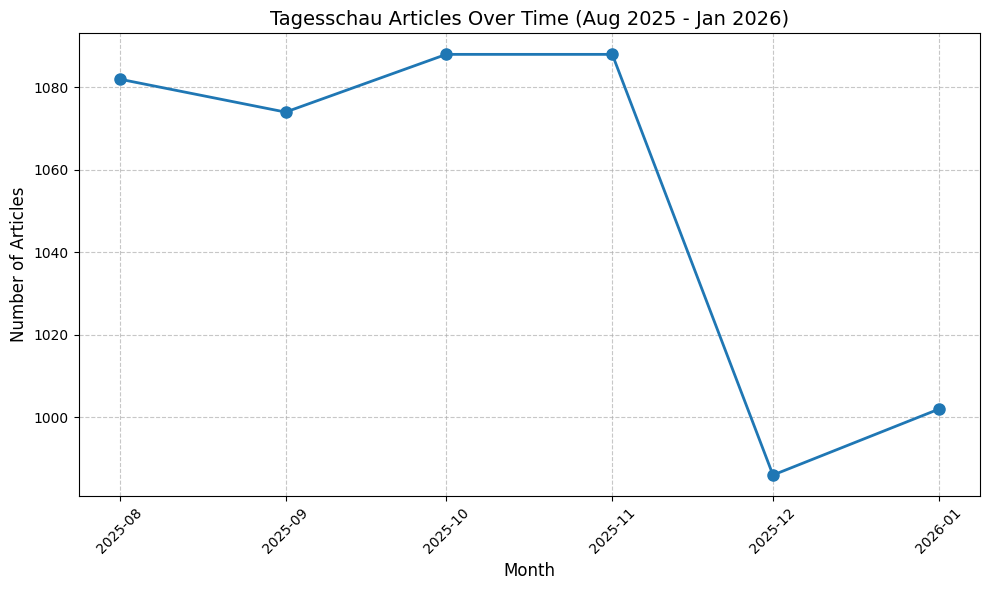

In [24]:
import matplotlib.pyplot as plt

# Create a time series plot of articles per month
fig, ax = plt.subplots(figsize=(10, 6))

# Convert period to timestamp for plotting
articles_per_month['month_ts'] = articles_per_month['month'].dt.to_timestamp()

ax.plot(articles_per_month['month_ts'], articles_per_month['article_count'], marker='o', linewidth=2, markersize=8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Tagesschau Articles Over Time (Aug 2025 - Jan 2026)', fontsize=14)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/var/folders/_q/1md1f9cs5rqdj5k3g3mxp5240000gp/T/ipykernel_82854/488552697.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(df_clean['Date'].dt.to_period('W'))


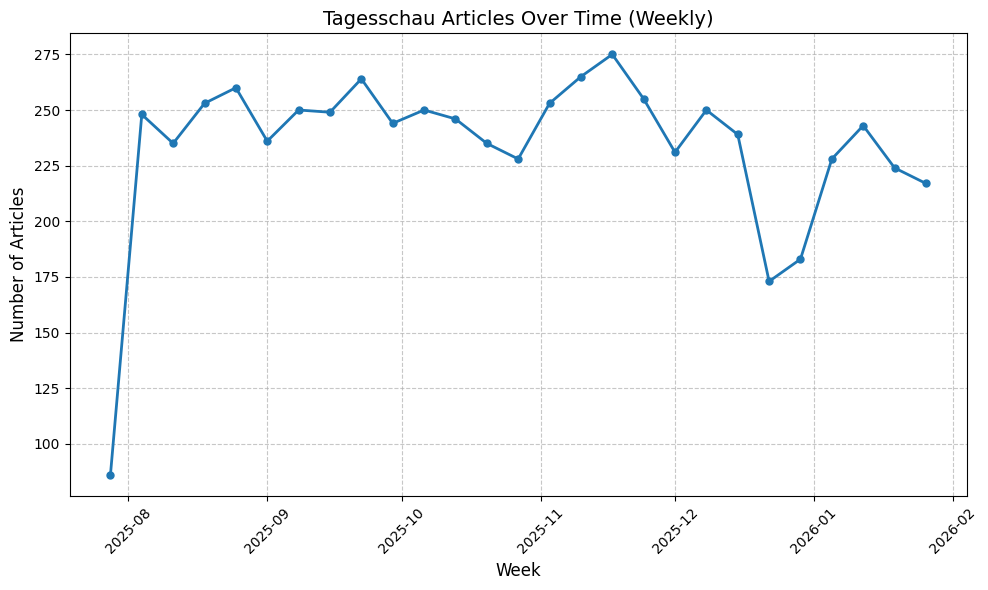

In [25]:
import matplotlib.pyplot as plt

# Create weekly counts
articles_per_week = (
    df_clean
    .groupby(df_clean['Date'].dt.to_period('W'))
    .size()
    .reset_index(name='article_count')
)
articles_per_week.columns = ['week', 'article_count']

# Convert period to timestamp for plotting
articles_per_week['week_ts'] = articles_per_week['week'].dt.to_timestamp()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(articles_per_week['week_ts'], articles_per_week['article_count'], marker='o', linewidth=2, markersize=5)

ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Tagesschau Articles Over Time (Weekly)', fontsize=14)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


NA count in 'ressort': 382


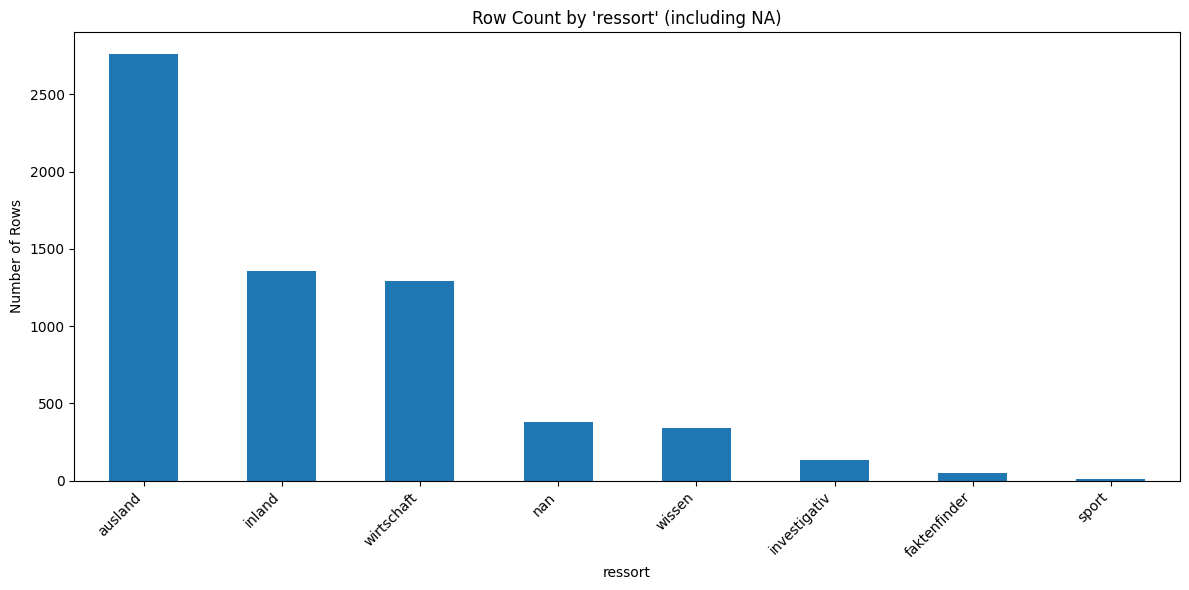

In [26]:
# Count values and NAs in ressort
ressort_counts = df_clean["ressort"].value_counts(dropna=False)
na_count = df_clean["ressort"].isna().sum()

print(f"NA count in 'ressort': {na_count}")

# Plot counts (including NA as category)
plot_counts = ressort_counts.copy()
plot_counts.index = plot_counts.index.astype(str)

plt.figure(figsize=(12, 6))
plot_counts.sort_values(ascending=False).plot(kind="bar")
plt.xlabel("ressort")
plt.ylabel("Number of Rows")
plt.title("Row Count by 'ressort' (including NA)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [27]:
df_clean["article_length_words"] = df_clean["Text"].str.split().str.len()
df_clean["article_length_chars"] = df_clean["Text"].str.len()

df_clean["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)


count    6320.0
mean      600.8
std       426.5
min         0.0
10%       284.0
25%       381.0
50%       523.5
75%       702.0
90%       916.0
95%      1099.0
99%      2500.8
max      8360.0
Name: article_length_words, dtype: float64

In [28]:
# Example article from "Wissen" and "Sport" ressort
for ressort_name in ["Wissen", "Sport"]:
    sample = (
        df_clean.loc[
            df_clean["ressort"].astype(str).str.lower().eq(ressort_name.lower()),
            ["Title", "Date", "ressort", "Text"]
        ]
        .dropna(subset=["Text"])
        .head(1)
    )

    print(f"\n--- Example from ressort: {ressort_name} ---")
    if sample.empty:
        print("No article found.")
    else:
        with pd.option_context("display.max_colwidth", None, "display.width", None):
            display(sample)


--- Example from ressort: Wissen ---


Title  \
3058  Wettrennen um die besten Akkus für Elektroautos   

                          Date ressort  \
3058 2025-08-28 00:00:00+02:00  wissen   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        


--- Example from ressort: Sport ---


,Title,Date,ressort,Text
2386,Deutsche Basketballer erreichen EM-Finale,2025-09-12 00:00:00+02:00,sport,"Die deutsche Basketball-Nationalmannschaft steht im EM-Finale. Das Team besiegte Finnland mit 98:86. Am Sonntag treffen die Deutschen dann auf die Türkei oder Griechenland. Basketball-Weltmeister Deutschland steht im Finale der Europameisterschaft und hat am Sonntag die Chance auf den nächsten großen Titel. Das Team um Kapitän Dennis Schröder besiegte im lettischen Riga Außenseiter Finnland im Halbfinale deutlich mit 98:86 (61:47) und sorgte vor 10.047 Zuschauern für den ersten deutschen EM-Finaleinzug seit 2005 mit Dirk Nowitzki. Im Endspiel am Sonntag treffen die Deutschen auf die Türkei oder Griechenland, die im Anschluss das zweite Halbfinale absolvieren. Bester deutscher Werfer war Schröder mit 26 Punkten. Vor zwei Jahren hatte Deutschland in Manila erstmals den WM-Titel gewonnen."


In [29]:
# Remove all rows where ressort is "Sport" (case-insensitive)
df_cleaned = df_clean.loc[
    ~df_clean["ressort"].astype(str).str.strip().str.lower().eq("sport")
].copy()

print(df_cleaned["ressort"].value_counts(dropna=False).head())
print("New shape:", df_cleaned.shape)

ressort
ausland       2763
inland        1357
wirtschaft    1293
NaN            382
wissen         339
Name: count, dtype: int64
New shape: (6312, 12)


In [30]:
#!pip install seaborn

In [31]:
import seaborn as sns

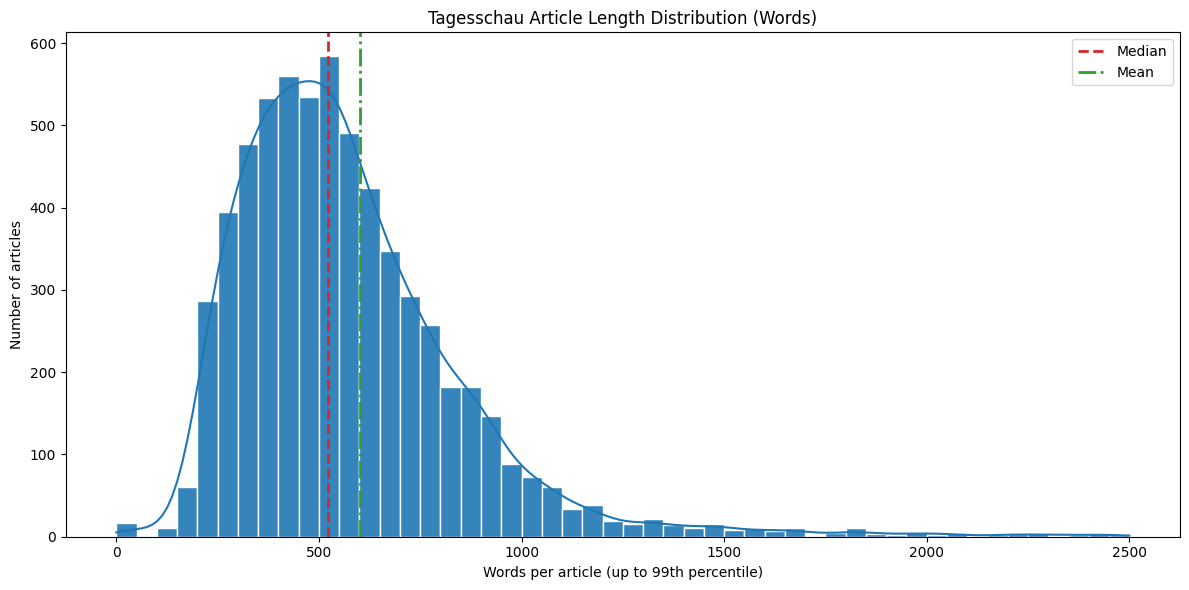

In [32]:
q99 = df_clean["article_length_words"].quantile(0.99)
length_plot = df_clean[df_clean["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(df_clean["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(df_clean["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Tagesschau Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()


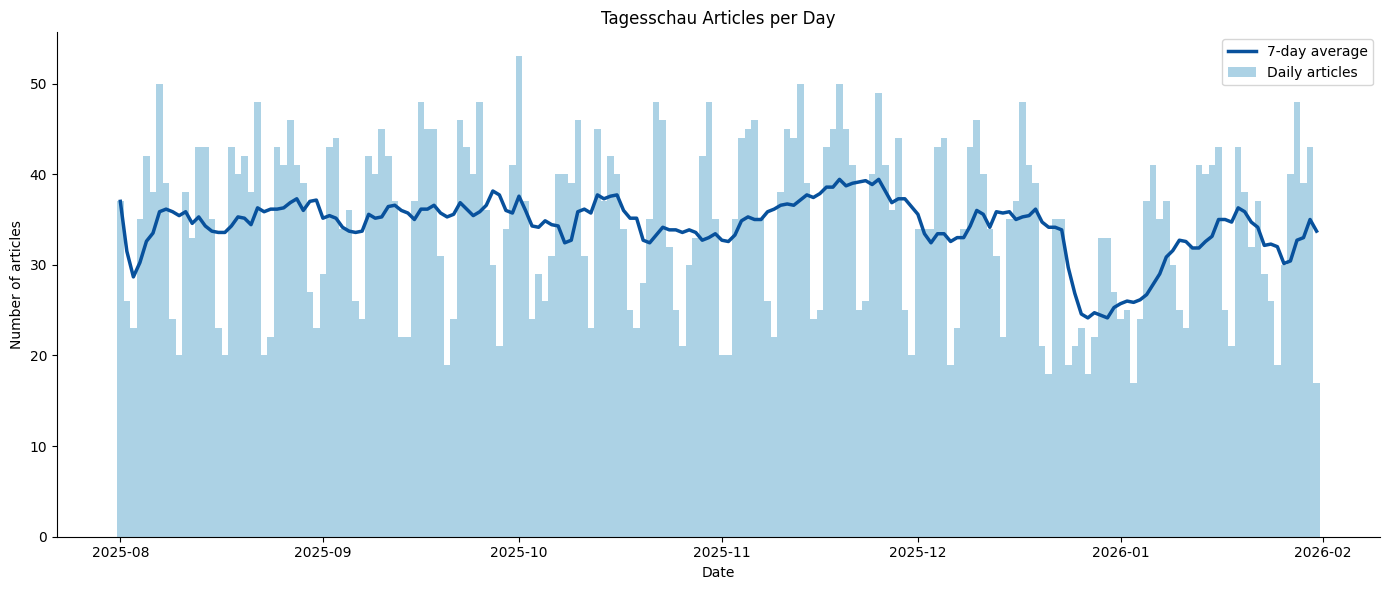

In [33]:
# Ensure datetime
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")

# Daily article counts (include missing days as 0)
daily_counts = (
    df_clean.dropna(subset=["Date"])
    .assign(Date=lambda d: d["Date"].dt.floor("D"))
    .groupby("Date")
    .size()
    .rename("articles")
    .sort_index()
    .asfreq("D", fill_value=0)
    .reset_index()
)

# 7-day rolling average
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.85,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("Tagesschau Articles per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

In [34]:
tagesschau_clean = df_clean.copy()
tagesschau_clean["source"] = "Tagesschau"
tagesschau_clean = tagesschau_clean[["Date", "Title", "Text", "source"]].copy()
tagesschau_clean_path = PROJECT_ROOT / "data preprocessing" / "tagesschau_clean.csv"
tagesschau_clean.to_csv(tagesschau_clean_path, index=False, encoding="utf-8")
print(f"Saved cleaned Tagesschau corpus: {len(tagesschau_clean):,} rows -> {tagesschau_clean_path}")

Saved cleaned Tagesschau corpus: 6,320 rows -> /Users/MattisHaumann/Dev/Thesis/data preprocessing/tagesschau_clean.csv


## BERTopic

In [35]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

project_root = resolve_project_root()
module_root = project_root / "1a_BERTopic"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

In [36]:
from bertopic_config import BERTopicConfig
from bertopic_pipeline import run_bertopic_pipeline

In [37]:
from pathlib import Path
import sys
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CANONICAL_COMBINED_PATH = PROJECT_ROOT / "00_Initial EDA" / "df_combined.csv"
df_combined = pd.read_csv(CANONICAL_COMBINED_PATH)
df_clean = (
    df_combined.loc[df_combined["source"].eq("Tagesschau")]
    .copy()
    .reset_index(drop=True)
)
print(f"Loaded canonical Tagesschau subset from df_combined: {len(df_clean):,} rows")


Loaded canonical Tagesschau subset from df_combined: 6,320 rows


In [38]:
# Legacy baseline run kept for reference only.
# Disabled on purpose so the notebook has one canonical Tagesschau fit below.
# result_full_text = run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Text",
#     config=BERTopicConfig(),
#     id_col="row_id",
#     source_name="Tagesschau",
# )


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 21:05:15,159 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/198 [00:00<?, ?it/s]

2026-03-31 21:06:12,669 - BERTopic - Embedding - Completed ✓
2026-03-31 21:06:12,672 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 21:06:32,124 - BERTopic - Dimensionality - Completed ✓
2026-03-31 21:06:32,127 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 21:06:32,279 - BERTopic - Cluster - Completed ✓
2026-03-31 21:06:32,285 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 21:06:37,696 - BERTopic - Representation - Completed ✓


In [ ]:
print("Legacy Tagesschau preview disabled. Use the canonical `result_ts` / `result` preview cells below.")


In [42]:
# pip install gensim
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


# Helper functions loaded.
# Run the canonical `result_ts` / `result` fit cell below first, then evaluate coherence there.
print("Tagesschau evaluation helpers loaded. Run the canonical fit below before computing metrics.")

{'coherence_npmi': 0.11901008436692163,
 'topic_diversity': 0.8675324675324675,
 'num_topics': 77,
 'top_k': 10}

In [43]:
# Legacy exploratory run kept for reference only.
# Disabled on purpose. This was the coarser clustering alternative tested before
# settling on the final Tagesschau specification below.
# result = run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Text",
#     config=BERTopicConfig(
#     hdbscan_min_cluster_size=25,
#     hdbscan_min_samples=4,
#     umap_n_neighbors=45,
#     umap_min_dist=0.05,
# ),
#     id_col="row_id",
#     source_name="Tagesschau",
# )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 21:08:52,696 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/198 [00:00<?, ?it/s]

2026-03-31 21:09:43,864 - BERTopic - Embedding - Completed ✓
2026-03-31 21:09:43,869 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 21:10:02,482 - BERTopic - Dimensionality - Completed ✓
2026-03-31 21:10:02,492 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 21:10:02,661 - BERTopic - Cluster - Completed ✓
2026-03-31 21:10:02,669 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 21:10:08,738 - BERTopic - Representation - Completed ✓


In [ ]:
print("Legacy Tagesschau preview disabled. Use the canonical `result_ts` / `result` preview cells below.")


In [45]:
# Canonical final Tagesschau run.
# The parameters tuned/played around with here were `hdbscan_min_cluster_size`,
# `hdbscan_min_samples`, `umap_n_neighbors`, and `umap_min_dist`.
# Final choice: `hdbscan_min_cluster_size=35`, `hdbscan_min_samples=2`,
# `umap_n_neighbors=25`, and `umap_min_dist=0.0` on the full-text corpus.
result_ts = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(
    hdbscan_min_cluster_size=35,
    hdbscan_min_samples=2,
    umap_n_neighbors=25,
    umap_min_dist=0.0,
),
    id_col="row_id",
    source_name="Tagesschau",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_ts


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 21:10:20,248 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/198 [00:00<?, ?it/s]

2026-03-31 21:11:06,437 - BERTopic - Embedding - Completed ✓
2026-03-31 21:11:06,439 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 21:11:20,556 - BERTopic - Dimensionality - Completed ✓
2026-03-31 21:11:20,557 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 21:11:20,671 - BERTopic - Cluster - Completed ✓
2026-03-31 21:11:20,681 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 21:11:26,302 - BERTopic - Representation - Completed ✓


In [46]:
topic_info_ts = result_ts["topic_info"]
topic_info_ts.head(45)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1410,-1_trump_ukraine_russland_epstein,"[trump, ukraine, russland, epstein, russischen...",[Der ukrainische Präsident Selenskyj fordert e...
1,0,443,0_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i...",[Beim israelischen Militär laufen laut Spreche...
2,1,275,1_ukraine_putin_selenskyj_russland,"[ukraine, putin, selenskyj, russland, trump, r...",[US-Präsident Trump hat Medienberichten zufolg...
3,2,235,2_dax_dollar_fed_anleger,"[dax, dollar, fed, anleger, punkten, aktien, k...",[Die starken Quartalsberichte der Techgiganten...
4,3,205,3_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado...",[Die USA haben Venezuela angegriffen und nach ...
5,4,163,4_patienten_medikamente_studie_studien,"[patienten, medikamente, studie, studien, erkr...",[Die geplante Apothekenreform nimmt Gestalt an...
6,5,153,5_bundesanwaltschaft_gericht_haft_prozess,"[bundesanwaltschaft, gericht, haft, prozess, s...",[Die Bundesanwaltschaft hält einen 49 Jahre al...
7,6,143,6_ki_google_online_kommission,"[ki, google, online, kommission, nutzer, eu ko...",[Google baut nun auch in Europa einen KI-Modus...
8,7,140,7_china_xi_peking_trump,"[china, xi, peking, trump, chinas, taiwan, chi...",[China hat auf die Zoll-Drohungen von US-Präsi...
9,8,134,8_rente_beschäftigten_studie_arbeitsmarkt,"[rente, beschäftigten, studie, arbeitsmarkt, m...",[Von Aktivrente bis Wehrdienst: 2026 wird sich...


In [47]:
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.10467014958352772,
 'topic_diversity': 0.8492063492063492,
 'num_topics': 63,
 'top_k': 10}

In [48]:
#Intertopic distance map
result_ts["topic_model"].visualize_topics()

In [ ]:
# # In 06_Tagesschau.ipynb
# ts_model = result_ts["topic_model"]
# PROJECT_ROOT = Path.cwd().resolve().parent  # if notebook is in "data preprocessing"
# ts_model.save(
#     PROJECT_ROOT / "BERTopic" / "outputs" / "ts_model",
#     serialization="safetensors",
#     save_ctfidf=True,
#     save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
# )


In [ ]:
# # In 06_Tagesschau.ipynb (after result_full_text is created)
# import joblib
# from pathlib import Path

# PROJECT_ROOT = Path.cwd().resolve().parent  # if notebook is in "data preprocessing"
# result_ts = result_full_text
# joblib.dump(result_ts, PROJECT_ROOT / "BERTopic" / "outputs" / "result_ts.joblib")


6it [00:29,  4.93s/it]


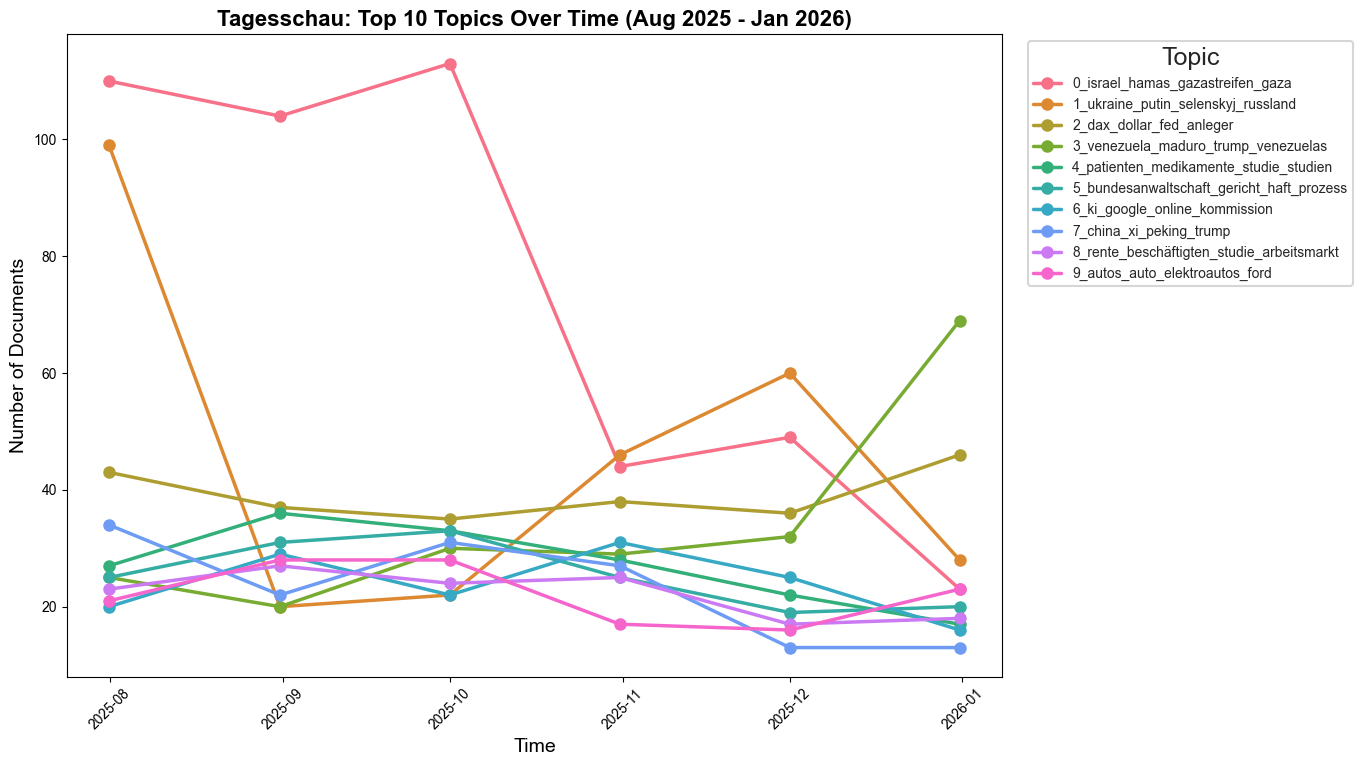

In [49]:
# Prepare data for topics over time using the final reduced model if it already exists.
# Re-run this cell after outlier reduction to pick up `result_ts_reduced`.
topic_time_result = result_ts_reduced if "result_ts_reduced" in globals() else result_ts

topic_info_time = topic_time_result["topic_info"].copy()
prepared_docs_time = topic_time_result["prepared_documents"]
date_col = "Date" if "Date" in prepared_docs_time.columns else "day"
prepared_dates = pd.to_datetime(prepared_docs_time[date_col], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()

docs_for_time = [doc for doc, ok in zip(topic_time_result["docs"], valid_time_mask) if ok]
topics_for_time = [topic for topic, ok in zip(topic_time_result["topics"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = topic_time_result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    topics=topics_for_time,
    nr_bins=6,
)

topic_info_non_outliers = topic_info_time.loc[topic_info_time["Topic"] != -1].copy()
if "DisplayTopic" in topic_info_non_outliers.columns:
    top_10_topics = topic_info_non_outliers.nsmallest(10, "DisplayTopic")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["DisplayLabel"]))
else:
    top_10_topics = topic_info_non_outliers.nlargest(10, "Count")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["Name"]))

topics_over_time_filtered = topics_over_time[topics_over_time["Topic"].isin(top_10_topics)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered["Topic"] == topic]
    label = label_map.get(topic, f"Topic {topic}")
    ax.plot(
        topic_data["Timestamp"],
        topic_data["Frequency"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=palette[i],
        label=label,
    )

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Number of Documents", fontsize=14)
ax.set_title("Tagesschau: Top 10 Topics Over Time (Aug 2025 - Jan 2026)", fontsize=16, fontweight="bold")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Outlier Reduction (focused section)

This section starts from the already fitted Tagesschau topic model (`result_ts`) and keeps the reduction workflow compact.

> **Final downstream workflow:** use the canonical final Tagesschau fit above, then apply `reduce_outliers(..., strategy="c-tf-idf", threshold=0.10)`.


In [50]:
import pandas as pd
from copy import deepcopy
from IPython.display import HTML, display

# Keep aligned with the exact model run defined above (result_ts).
base_result = result_ts
topic_model_base = base_result["topic_model"]
docs_ts = base_result["docs"]
topics_ts = list(base_result["topics"])
prepared_ts = base_result["prepared_documents"].copy()

print(f"Documents: {len(docs_ts):,}")
print(f"Initial outliers (-1): {(pd.Series(topics_ts) == -1).sum():,}")

Documents: 6,319
Initial outliers (-1): 1,410


## Reduced outlier experiments (short)

A compact set of variations to show what was tested before choosing the final threshold setup.

<details>
<summary>Archived notes from longer experiments (fold to ignore)</summary>

- Earlier notebook drafts also tested: `probabilities` (0.85/0.90), `embeddings`, and chained variants.
- Those longer blocks were removed here to keep this notebook focused; final downstream work uses one method only.

</details>


In [51]:
experiment_topics = {
    "distributions": topic_model_base.reduce_outliers(docs_ts, topics_ts, strategy="distributions"),
    "c-tf-idf_default": topic_model_base.reduce_outliers(docs_ts, topics_ts, strategy="c-tf-idf"),
    "c-tf-idf_threshold_0.10": topic_model_base.reduce_outliers(
        docs_ts, topics_ts, strategy="c-tf-idf", threshold=0.10
    ),
}

rows = []
for name, new_topics in experiment_topics.items():
    rows.append({
        "experiment": name,
        "outliers_before": int((pd.Series(topics_ts) == -1).sum()),
        "outliers_after": int((pd.Series(new_topics) == -1).sum()),
        "reassigned_from_-1": int(((pd.Series(topics_ts) == -1) & (pd.Series(new_topics) != -1)).sum()),
        "changed_total": int((pd.Series(topics_ts) != pd.Series(new_topics)).sum()),
    })

experiments_summary = pd.DataFrame(rows).sort_values(["outliers_after", "changed_total"]).reset_index(drop=True)
display(experiments_summary)

100%|██████████| 2/2 [00:05<00:00,  2.70s/it]


,experiment,outliers_before,outliers_after,reassigned_from_-1,changed_total
0,distributions,1410,0,1410,1410
1,c-tf-idf_default,1410,0,1410,1410
2,c-tf-idf_threshold_0.10,1410,744,666,666


## Final Method (Use This One)

> **Primary and only downstream method:** `reduce_outliers(..., strategy="c-tf-idf", threshold=0.10)`

The model components (vectorizer, c-TF-IDF, representation model) are kept consistent while only topic assignments are updated.


In [52]:
import pandas as pd
from copy import deepcopy

# Keep aligned with the exact reduced-model baseline selected above (result_ts).
base_result = result_ts
topic_model_base = base_result["topic_model"]
docs_ts = list(base_result["docs"])
topics_ts = list(base_result["topics"])
prepared_docs = base_result["prepared_documents"].copy()
baseline_topic_ids = {topic for topic in topics_ts if topic != -1}

new_topics_ctfidf_threshold = topic_model_base.reduce_outliers(
    docs_ts,
    topics_ts,
    strategy="c-tf-idf",
    threshold=0.10,
)
new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_base)
vectorizer_same = deepcopy(topic_model_base.vectorizer_model)
ctfidf_same = deepcopy(topic_model_base.ctfidf_model)
representation_same = deepcopy(topic_model_base.representation_model)

topic_model_ctfidf_threshold.update_topics(
    docs_ts,
    topics=new_topics_ctfidf_threshold,
    vectorizer_model=vectorizer_same,
    ctfidf_model=ctfidf_same,
    representation_model=representation_same,
    top_n_words=topic_model_base.top_n_words,
)
topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_info_ctfidf_threshold["OriginalTopic"] = topic_info_ctfidf_threshold["Topic"]
topic_info_ctfidf_threshold["TopicNameClean"] = topic_info_ctfidf_threshold["Name"].str.replace(r"^\d+_", "", regex=True)

ranked_topics = (
    topic_info_ctfidf_threshold.loc[topic_info_ctfidf_threshold["Topic"] != -1, ["Topic", "Count"]]
    .sort_values(["Count", "Topic"], ascending=[False, True])
    .reset_index(drop=True)
)
ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))

topic_info_ctfidf_threshold["DisplayTopic"] = (
    topic_info_ctfidf_threshold["Topic"].map(display_topic_map).astype("Int64")
)
topic_info_ctfidf_threshold["DisplayLabel"] = topic_info_ctfidf_threshold.apply(
    lambda row: "Outliers"
    if row["Topic"] == -1
    else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
    axis=1,
)

ordered_cols = ["OriginalTopic", "DisplayTopic", "DisplayLabel", "TopicNameClean"]
remaining_cols = [col for col in topic_info_ctfidf_threshold.columns if col not in ordered_cols]
topic_info_ctfidf_threshold = topic_info_ctfidf_threshold[ordered_cols + remaining_cols]

topic_name_map_reduced = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"]))
display_label_map = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["DisplayLabel"]))

doc_info_reduced = base_result["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)
doc_info_reduced["DisplayTopic"] = doc_info_reduced["Topic"].map(display_topic_map).astype("Int64")
doc_info_reduced["DisplayLabel"] = doc_info_reduced["Topic"].map(display_label_map)

result_ts_reduced = dict(base_result)
result_ts_reduced["topics"] = list(new_topics_ctfidf_threshold)
result_ts_reduced["topic_model"] = topic_model_ctfidf_threshold
result_ts_reduced["topic_info"] = topic_info_ctfidf_threshold
result_ts_reduced["topic_info_display"] = topic_info_ctfidf_threshold.copy()
result_ts_reduced["doc_info"] = doc_info_reduced
result_ts_reduced["display_topic_map"] = display_topic_map
result_ts_reduced["display_label_map"] = display_label_map

summary_final = pd.DataFrame([
    {"Variant": "baseline", "Outlier_Count": int((pd.Series(topics_ts) == -1).sum())},
    {"Variant": "ctfidf_threshold_0.10", "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum())},
])
display(summary_final)
display(topic_info_ctfidf_threshold.head(20))

2026-03-31 21:12:47,241 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Variant,Outlier_Count
0,baseline,1410
1,ctfidf_threshold_0.10,744


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_papst_leo_erde_kirk,-1,744,-1_papst_leo_erde_kirk,"[papst, leo, erde, kirk, mond, kirche, andrew,...",[Der ukrainische Präsident Selenskyj fordert e...
1,0,1,Topic 1 — israel_hamas_gazastreifen_gaza,israel_hamas_gazastreifen_gaza,0,448,0_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i...",[Beim israelischen Militär laufen laut Spreche...
2,1,2,Topic 2 — ukraine_putin_selenskyj_russland,ukraine_putin_selenskyj_russland,1,323,1_ukraine_putin_selenskyj_russland,"[ukraine, putin, selenskyj, russland, trump, r...",[US-Präsident Trump hat Medienberichten zufolg...
3,2,3,Topic 3 — dollar_dax_fed_anleger,dollar_dax_fed_anleger,2,264,2_dollar_dax_fed_anleger,"[dollar, dax, fed, anleger, punkten, aktien, a...",[Die starken Quartalsberichte der Techgiganten...
4,3,4,Topic 4 — venezuela_maduro_trump_venezuelas,venezuela_maduro_trump_venezuelas,3,207,3_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado...",[Die USA haben Venezuela angegriffen und nach ...
5,4,6,Topic 6 — patienten_medikamente_studie_studien,patienten_medikamente_studie_studien,4,175,4_patienten_medikamente_studie_studien,"[patienten, medikamente, studie, studien, erkr...",[Die geplante Apothekenreform nimmt Gestalt an...
6,5,7,Topic 7 — bundesanwaltschaft_gericht_haft_prozess,bundesanwaltschaft_gericht_haft_prozess,5,159,5_bundesanwaltschaft_gericht_haft_prozess,"[bundesanwaltschaft, gericht, haft, prozess, s...",[Die Bundesanwaltschaft hält einen 49 Jahre al...
7,6,5,Topic 5 — ki_google_online_kommission,ki_google_online_kommission,6,178,6_ki_google_online_kommission,"[ki, google, online, kommission, shein, nutzer...",[Google baut nun auch in Europa einen KI-Modus...
8,7,10,Topic 10 — china_xi_indien_peking,china_xi_indien_peking,7,147,7_china_xi_indien_peking,"[china, xi, indien, peking, trump, chinas, chi...",[China hat auf die Zoll-Drohungen von US-Präsi...
9,8,8,Topic 8 — rente_beschäftigten_arbeitsmarkt_studie,rente_beschäftigten_arbeitsmarkt_studie,8,150,8_rente_beschäftigten_arbeitsmarkt_studie,"[rente, beschäftigten, arbeitsmarkt, studie, m...",[Von Aktivrente bis Wehrdienst: 2026 wird sich...


### Save final reduced model (`ts_model` overwrite)

Persist the final threshold-based reduced model so this is the canonical saved Tagesschau model in `1a_BERTopic/outputs/ts_model` for downstream loading and merged-model use.


In [53]:
from pathlib import Path
import shutil

# Keep a reusable reduced result dict in notebook memory and save the canonical final Tagesschau model to outputs/.
result_ts = result_ts_reduced
topic_info = result_ts["topic_info"]

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")

project_root = find_project_root(Path.cwd())
save_dir = project_root / "1a_BERTopic" / "outputs" / "ts_model"
save_dir.parent.mkdir(parents=True, exist_ok=True)
if save_dir.exists():
    shutil.rmtree(save_dir)

topic_model_ctfidf_threshold.save(
    save_dir,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

print(f"Saved final reduced model to: {save_dir}")

Saved final reduced model to: /Users/MattisHaumann/Dev/Thesis/1a_BERTopic/outputs/ts_model


In [54]:
# Unified display numbering for the final reduced model (largest topic = Topic 1).
topic_display_result = result_ts_reduced if "result_ts_reduced" in globals() else result_ts
topic_info = topic_display_result["topic_info"].copy()
display_topic_map = topic_display_result["display_topic_map"]
display_label_map = topic_display_result["display_label_map"]

display(topic_info.head(20))

,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_papst_leo_erde_kirk,-1,744,-1_papst_leo_erde_kirk,"[papst, leo, erde, kirk, mond, kirche, andrew,...",[Der ukrainische Präsident Selenskyj fordert e...
1,0,1,Topic 1 — israel_hamas_gazastreifen_gaza,israel_hamas_gazastreifen_gaza,0,448,0_israel_hamas_gazastreifen_gaza,"[israel, hamas, gazastreifen, gaza, geiseln, i...",[Beim israelischen Militär laufen laut Spreche...
2,1,2,Topic 2 — ukraine_putin_selenskyj_russland,ukraine_putin_selenskyj_russland,1,323,1_ukraine_putin_selenskyj_russland,"[ukraine, putin, selenskyj, russland, trump, r...",[US-Präsident Trump hat Medienberichten zufolg...
3,2,3,Topic 3 — dollar_dax_fed_anleger,dollar_dax_fed_anleger,2,264,2_dollar_dax_fed_anleger,"[dollar, dax, fed, anleger, punkten, aktien, a...",[Die starken Quartalsberichte der Techgiganten...
4,3,4,Topic 4 — venezuela_maduro_trump_venezuelas,venezuela_maduro_trump_venezuelas,3,207,3_venezuela_maduro_trump_venezuelas,"[venezuela, maduro, trump, venezuelas, machado...",[Die USA haben Venezuela angegriffen und nach ...
5,4,6,Topic 6 — patienten_medikamente_studie_studien,patienten_medikamente_studie_studien,4,175,4_patienten_medikamente_studie_studien,"[patienten, medikamente, studie, studien, erkr...",[Die geplante Apothekenreform nimmt Gestalt an...
6,5,7,Topic 7 — bundesanwaltschaft_gericht_haft_prozess,bundesanwaltschaft_gericht_haft_prozess,5,159,5_bundesanwaltschaft_gericht_haft_prozess,"[bundesanwaltschaft, gericht, haft, prozess, s...",[Die Bundesanwaltschaft hält einen 49 Jahre al...
7,6,5,Topic 5 — ki_google_online_kommission,ki_google_online_kommission,6,178,6_ki_google_online_kommission,"[ki, google, online, kommission, shein, nutzer...",[Google baut nun auch in Europa einen KI-Modus...
8,7,10,Topic 10 — china_xi_indien_peking,china_xi_indien_peking,7,147,7_china_xi_indien_peking,"[china, xi, indien, peking, trump, chinas, chi...",[China hat auf die Zoll-Drohungen von US-Präsi...
9,8,8,Topic 8 — rente_beschäftigten_arbeitsmarkt_studie,rente_beschäftigten_arbeitsmarkt_studie,8,150,8_rente_beschäftigten_arbeitsmarkt_studie,"[rente, beschäftigten, arbeitsmarkt, studie, m...",[Von Aktivrente bis Wehrdienst: 2026 wird sich...


### UMAP topic map (reduced model, no re-fit)

Visualize the final reduced topics from the threshold workflow above.


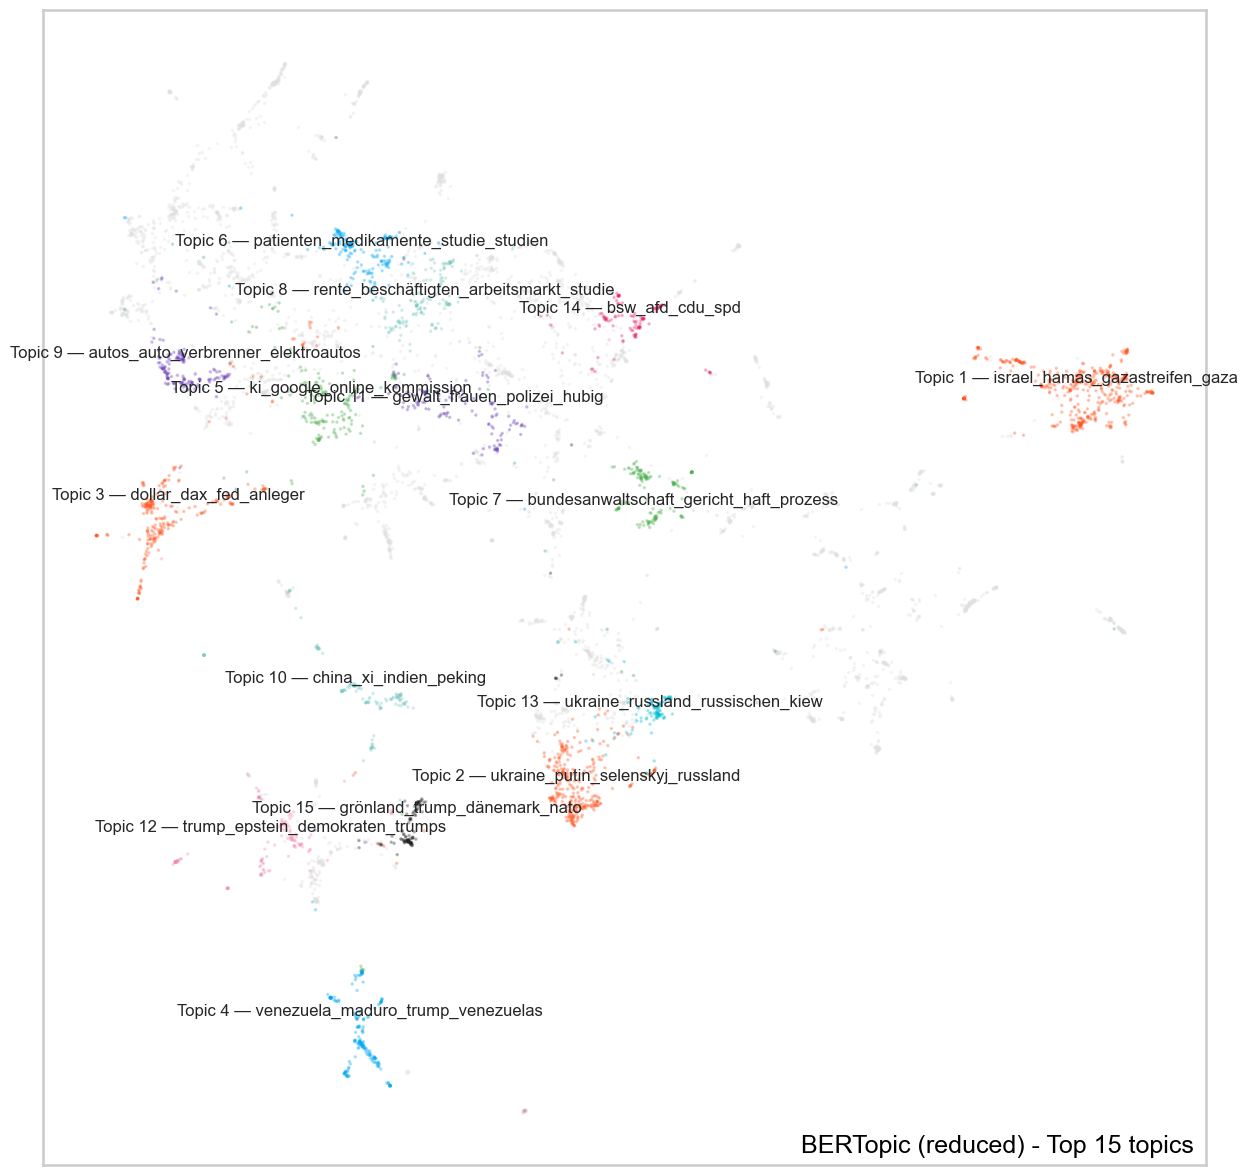

In [55]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP

run_result = result_ts_reduced if "result_ts_reduced" in globals() else result_ts
topic_model_plot = run_result["topic_model"]
docs_plot = list(run_result["docs"])
topics_plot = list(run_result["topics"])
topic_info_plot = run_result["topic_info"].copy()
display_label_map = run_result["display_label_map"]

embeddings = topic_model_plot._extract_embeddings(docs_plot, method="document")
umap_model = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric="cosine").fit(embeddings)
df_plot = pd.DataFrame(umap_model.embedding_, columns=["x", "y"])
df_plot["topic"] = topics_plot

top_n = 15
fontsize = 12

top_topic_ids = (
    topic_info_plot.loc[topic_info_plot["Topic"] != -1]
    .nsmallest(top_n, "DisplayTopic")["Topic"]
    .tolist()
)

to_plot = df_plot.copy()
to_plot.loc[~to_plot["topic"].isin(top_topic_ids), "topic"] = -1
outliers = to_plot.loc[to_plot["topic"] == -1]
non_outliers = to_plot.loc[to_plot["topic"] != -1]

cmap = matplotlib.colors.ListedColormap([
    "#FF5722", "#03A9F4", "#4CAF50", "#80CBC4", "#673AB7",
    "#795548", "#E91E63", "#212121", "#00BCD4", "#CDDC39",
    "#AED581", "#FFE082", "#BCAAA4", "#B39DDB", "#F48FB1",
])

fig, ax = plt.subplots(figsize=(15, 15))
ax.scatter(outliers["x"], outliers["y"], c="#E0E0E0", s=1, alpha=0.3)
ax.scatter(non_outliers["x"], non_outliers["y"], c=non_outliers["topic"], s=1, alpha=0.3, cmap=cmap)

centroids = non_outliers.groupby("topic", as_index=False)[["x", "y"]].mean()
for _, row in centroids.iterrows():
    topic = int(row["topic"])
    label = display_label_map.get(topic, f"Topic {topic}")
    ax.text(row["x"], row["y"] * 1.01, label, fontsize=fontsize, horizontalalignment="center")

ax.text(0.99, 0.01, f"BERTopic (reduced) - Top {top_n} topics",
        transform=ax.transAxes, horizontalalignment="right", color="black")
plt.xticks([], [])
plt.yticks([], [])
plt.show()

### Reassigned articles from `-1` (where they moved now)

Show only a compact selection of articles that were originally outliers (`-1`) in `result_ts` and got reassigned by the final threshold method.


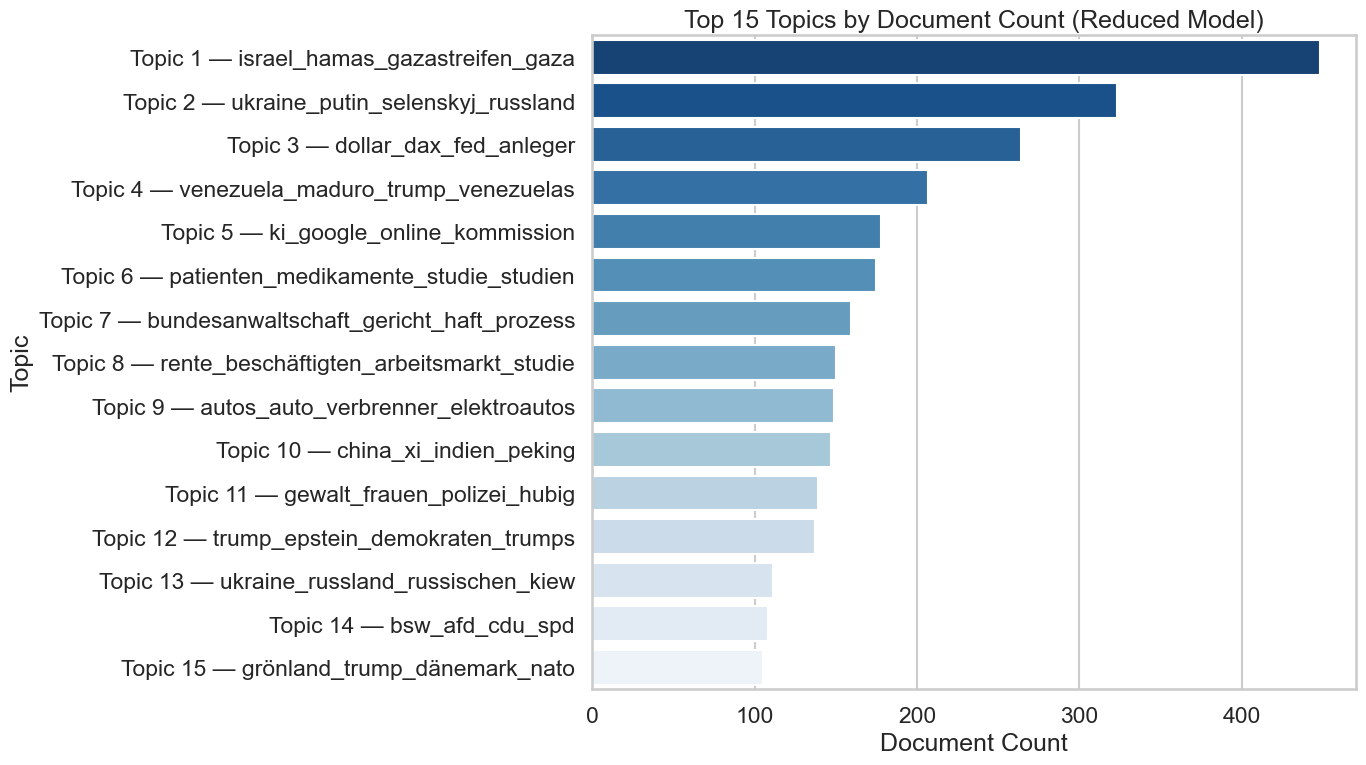

In [56]:
import seaborn as sns

# Ensure plotting libs exist in current kernel.
import matplotlib.pyplot as plt

# Re-run this cell after outlier reduction to visualize the final reduced model with unified topic numbering.
run_result = result_ts_reduced if "result_ts_reduced" in globals() else result_ts
topic_info_run = run_result["topic_info"].copy()

if "DisplayTopic" not in topic_info_run.columns:
    topic_info_run["OriginalTopic"] = topic_info_run["Topic"]
    topic_info_run["TopicNameClean"] = topic_info_run["Name"].str.replace(r"^\d+_", "", regex=True)
    ranked_topics = (
        topic_info_run.loc[topic_info_run["Topic"] != -1, ["Topic", "Count"]]
        .sort_values(["Count", "Topic"], ascending=[False, True])
        .reset_index(drop=True)
    )
    ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
    display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))
    topic_info_run["DisplayTopic"] = topic_info_run["Topic"].map(display_topic_map).astype("Int64")
    topic_info_run["DisplayLabel"] = topic_info_run.apply(
        lambda row: "Outliers"
        if row["Topic"] == -1
        else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
        axis=1,
    )

top15_topics = (
    topic_info_run.loc[topic_info_run["Topic"] != -1]
    .nsmallest(15, "DisplayTopic")
    .sort_values("DisplayTopic")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=top15_topics,
    x="Count",
    y="DisplayLabel",
    order=top15_topics["DisplayLabel"].tolist(),
    palette="Blues_r",
    ax=ax,
)

ax.set_title("Top 15 Topics by Document Count (Reduced Model)")
ax.set_xlabel("Document Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()

In [ ]:
comparison_df = prepared_ts[["original_index", "document_id"]].copy()
comparison_df["Topic_before"] = topics_ts
comparison_df["Topic_after"] = list(new_topics_ctfidf_threshold)

topic_name_map_after = (
    topic_model_ctfidf_threshold.get_topic_info()[["Topic", "Name"]]
    .drop_duplicates(subset=["Topic"])
    .set_index("Topic")["Name"]
    .to_dict()
)
comparison_df["Topic_after_name"] = comparison_df["Topic_after"].map(topic_name_map_after)

df_clean_with_index = df_clean.reset_index().rename(columns={"index": "original_index"})
comparison_df = comparison_df.merge(df_clean_with_index, on="original_index", how="left")

moved_from_outlier = comparison_df[(comparison_df["Topic_before"] == -1) & (comparison_df["Topic_after"] != -1)].copy()

where_now = (
    moved_from_outlier.groupby(["Topic_after", "Topic_after_name"], dropna=False)
    .size()
    .reset_index(name="docs_from_-1")
    .sort_values("docs_from_-1", ascending=False)
    .reset_index(drop=True)
)

print("Where former -1 documents moved to:")
display(where_now.head(15))

max_topics = 6
rows_per_topic = 5
selected_topics = where_now["Topic_after"].head(max_topics).tolist()

selection = (
    moved_from_outlier[moved_from_outlier["Topic_after"].isin(selected_topics)]
    .sort_values(["Topic_after", "Date"])
    .groupby("Topic_after", group_keys=False)
    .head(rows_per_topic)
    .copy()
)

def _preview_text(text, max_chars=500):
    if pd.isna(text):
        return ""
    text = " ".join(str(text).replace("\n", " ").split())
    if len(text) <= max_chars:
        return text
    cut = text[:max_chars]
    if " " in cut:
        cut = cut.rsplit(" ", 1)[0]
    return cut + " ..."

def _make_clickable(url):
    if pd.isna(url):
        return ""
    url = str(url).strip()
    if not url:
        return ""
    if not url.startswith(("http://", "https://")):
        url = "https://" + url.lstrip("/")
    return f'<a href="{url}" target="_blank" rel="noopener noreferrer">open article</a>'

url_col = next((c for c in ["URL", "Url", "url", "link"] if c in selection.columns), None)
if url_col is not None:
    selection["Article"] = selection[url_col].map(_make_clickable)
else:
    selection["Article"] = ""

selection["Text"] = selection["Text"].map(_preview_text)

show_cols = ["Date", "Title", "Topic_after", "Topic_after_name", "Article", "Text"]
show_df = selection[show_cols].rename(columns={
    "Topic_after": "Topic_now",
    "Topic_after_name": "Topic_name_now",
})

display(HTML(show_df.to_html(index=False, escape=False)))
print(f"Rows shown: {len(show_df):,} | Topics shown: {len(selected_topics):,}")

# Reusable tables
df_outlier_reassignment_ts = moved_from_outlier.copy()
df_outlier_reassignment_selection_ts = show_df.copy()
